# Applied Machine Learning
## by <i>Andreas Grotz</i>

## Table of Contents
- [Introduction](#intro)
- [Imports](#import)
- [Data Preparation and Preprocessing](#prep)
- [Model Selection and Training](#train)
- [Model Evaluation](#eval)
- [Summary](#summary)

<a id='intro'></a>
### Introduction

In this project, we complete a full machine learning workflow for a dataset on wine quality (https://archive.ics.uci.edu/dataset/186/wine+quality). This dataset contains two csv files on chemical properties and quality scores of red and white wines, respectively. We will focus on the white wine data in this project (file <i>winequality-white.csv</i>).

We start by loading, cleaning and rescaling the data. We then try to classify the quality using the chemical properties by fitting a decision tree model. We apply regularization techniques to avoid overfitting, evaluate the model performance, and conclude by a short summary of our findings.


<a id='import'></a>
### Imports

In this section, we import required Python modules, and we load our dataset to a Pandas dataframe.

In [1]:
#!pip install numpy
#!pip install pandas
#!pip install matplotlib
#!pip install seaborn
#!pip install scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [3]:
df = pd.read_csv("winequality-white.csv", delimiter=";")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


<a id='prep'></a>
### Data Preparation and Preprocessing

In this section, we explore the data and perform some cleaning and rescaling steps.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [5]:
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [6]:
sum(df.duplicated())

937

The dataset contains around 5,000 rows and twelve columns. Eleven columns are continous numerical variables that describe different chemical properties of the wines. The twelvth column is the target variable 'quality', which is an ordinal categorical variable describing a quality score with integer values from 0 to 10. 

There are no missing values in the data, but a significant amount of duplicates. Let us check the distribution of quality labels in the full dataset and among duplicates:

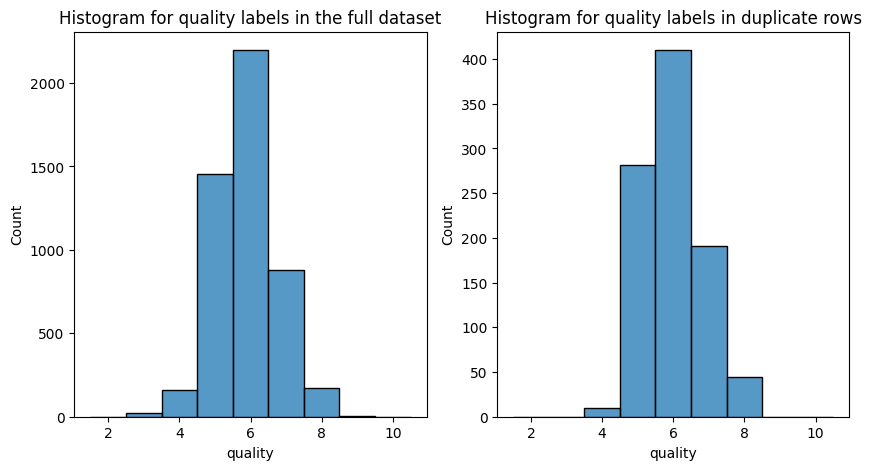

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('')
bins = [1.5,2.5,3.5,4.5,5.5,6.5,7.5,8.5,9.5,10.5]
sns.histplot(df, x='quality', bins=bins, ax=ax[0]);
sns.histplot(df[df.duplicated()], x='quality', bins=bins, ax=ax[1]);
ax[0].set(title='Histogram for quality labels in the full dataset')
ax[1].set(title='Histogram for quality labels in duplicate rows')
plt.show()

There are two observations to be made: First, quality labels are not balanced, but heavily centered in the 5, 6, and 7 buckets, with the 6 bucket containing more than half of the data points. Second, the distribution of quality labels in the duplicate rows is roughly the same as in the full dataset.

The question now is whether these duplicates are data errors that should be cleaned or whether they are genuine observations that should be kept. This cannot be finally decided, unless we knew more about the data collection process. It seems rather unlikely though that two distinct wines coincide exactly on eleven continuous properties, which is why we decide to drop the duplicates.

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000
mean,6.839346,0.280538,0.334332,5.914819,0.045905,34.889169,137.193512,0.993790,3.195458,0.490351,10.589358,5.854835
std,0.866860,0.103437,0.122446,4.861646,0.023103,17.210021,43.129065,0.002905,0.151546,0.113523,1.217076,0.890683
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.600000,0.035000,23.000000,106.000000,0.991620,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,4.700000,0.042000,33.000000,133.000000,0.993500,3.180000,0.480000,10.400000,6.000000
75%,7.300000,0.330000,0.390000,8.900000,0.050000,45.000000,166.000000,0.995710,3.290000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


We have around 4,000 rows in the cleaned dataset, and we next split the data into features and target variable, and we rescale the features to zero mean and unit variance.

In [10]:
# Split the data into features and target label
quality = df['quality']
features_raw = df.drop('quality', axis = 1)

In [11]:
scaler = StandardScaler()
features = pd.DataFrame(data = scaler.fit_transform(features_raw))
features.columns = features_raw.columns
features.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,3.961000e+03,3.961000e+03,3.961000e+03,3.961000e+03,3.961000e+03,3.961000e+03,3.961000e+03,3.961000e+03,3.961000e+03,3.961000e+03,3.961000e+03
mean,-7.462403e-16,1.524770e-16,-2.870155e-17,1.542708e-16,-5.166279e-16,1.022493e-16,2.296124e-16,1.254258e-14,1.313096e-15,-5.238033e-16,-1.865601e-16
std,1.000126e+00,1.000126e+00,1.000126e+00,1.000126e+00,1.000126e+00,1.000126e+00,1.000126e+00,1.000126e+00,1.000126e+00,1.000126e+00,1.000126e+00
min,-3.506599e+00,-1.938986e+00,-2.730789e+00,-1.093352e+00,-1.597636e+00,-1.911289e+00,-2.972698e+00,-2.299932e+00,-3.137791e+00,-2.381769e+00,-2.127792e+00
25%,-6.222624e-01,-6.820247e-01,-5.254587e-01,-8.876343e-01,-4.720853e-01,-6.909155e-01,-7.233509e-01,-7.470245e-01,-6.959724e-01,-7.078848e-01,-8.951743e-01
50%,-4.539499e-02,-1.985781e-01,-1.170642e-01,-2.499098e-01,-1.690523e-01,-1.097853e-01,-9.724396e-02,-9.969269e-02,-1.020166e-01,-9.119074e-02,-1.556039e-01
75%,5.314724e-01,4.782472e-01,4.546882e-01,6.141042e-01,1.772711e-01,5.875709e-01,6.679979e-01,6.612666e-01,6.239293e-01,5.255033e-01,6.661410e-01
max,8.492243e+00,7.923326e+00,1.082791e+01,1.231944e+01,1.299124e+01,1.476715e+01,7.021824e+00,1.556023e+01,4.121669e+00,5.194758e+00,2.967027e+00


As a last preparation step, we split the data into a training batch and a test batch.

In [12]:
# Split the 'features' and 'income' data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, quality, test_size = 0.2, random_state = 0)

<a id='train'></a>
### Model Selection and Training

We now fit a decision tree classifier to the training data. Decision tree classifiers are white-box models that include feature selection as part of the training process. We start by training a classifier with default settings:

In [13]:
decisionTreeClassifier = DecisionTreeClassifier()

In [14]:
decisionTreeClassifier.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [15]:
predictions_train = decisionTreeClassifier.predict(X_train)
predictions_test = decisionTreeClassifier.predict(X_test)
acc_train = accuracy_score(y_train, predictions_train)
acc_test = accuracy_score(y_test, predictions_test)
print(f'Training accuracy: {acc_train}')
print(f'Test accuracy: {acc_test}')
print(f'Node count: {decisionTreeClassifier.tree_.node_count}')

Training accuracy: 1.0
Test accuracy: 0.44388398486759145
Node count: 2003


The fact that the model perfectly fits the training data, but has an accuarcy below 50% for the test data is a clear sign of overfitting. The fact that the trained model has around 2,000 nodes for around 3,000 data points also indicates that the model has been tailored to the training data.

We therefore need to regularize the model in order to prevent overfitting. We do this by applying cost-complexity pruning, and we let sklearn do the heavy lifting in determining the pruning path for the regularization parameter alpha:

In [16]:
path = decisionTreeClassifier.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [17]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)

In [18]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

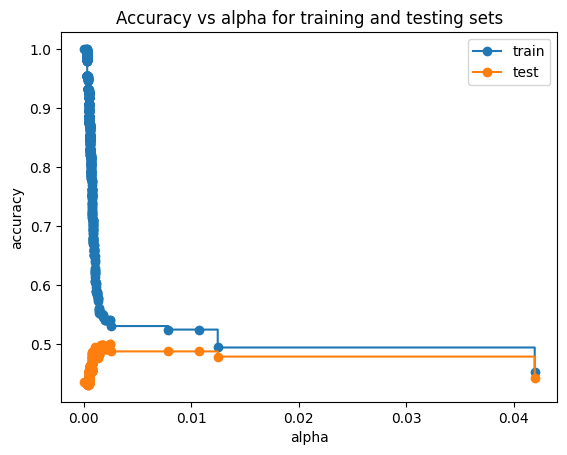

In [19]:
fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

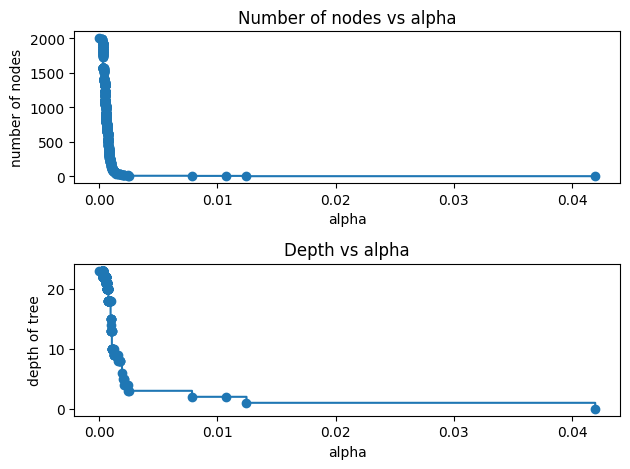

In [20]:
node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1)
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

The plots above show that there is a steep decrease in training accuarcy and a steep increase in test accuarcy, when the alpha parameter is tuned away from zero. This comes along with a steep decrease in the number of nodes and the depths of the tree.

All these curves are reaching a plateau at around alpha = 0.002, and actually this is also the model with the best test accuracy. We therefore choose our final model accordingly:

In [21]:
best_idx = np.argmax(test_scores)
alpha_opt = ccp_alphas[best_idx]
print(f'Best alpha for pruning: {alpha_opt}')
decisionTreeClassifier = clfs[best_idx]

Best alpha for pruning: 0.0024085635150196405


<a id='eval'></a>
### Model Evaluation

In this section, we evaluate our model using the accuracy score, and we explain some features of the model.

In [22]:
predictions_train_opt = decisionTreeClassifier.predict(X_train)
predictions_test_opt = decisionTreeClassifier.predict(X_test)
acc_train_opt = accuracy_score(y_train, predictions_train_opt)
acc_test_opt = accuracy_score(y_test, predictions_test_opt)
print(f'Training accuracy optimal model: {acc_train_opt}')
print(f'Test accuracy optimal model: {acc_test_opt}')
print(f'Node count optimal model: {decisionTreeClassifier.tree_.node_count}')

Training accuracy optimal model: 0.5416666666666666
Test accuracy optimal model: 0.5006305170239597
Node count optimal model: 13


The training accuracy of around 54% and test accuarcy of around 51% are rather close, and the tree has only 13 nodes now, indicating a good fit and no overfitting.

Next, let us check the relative importance of the chemical properties:

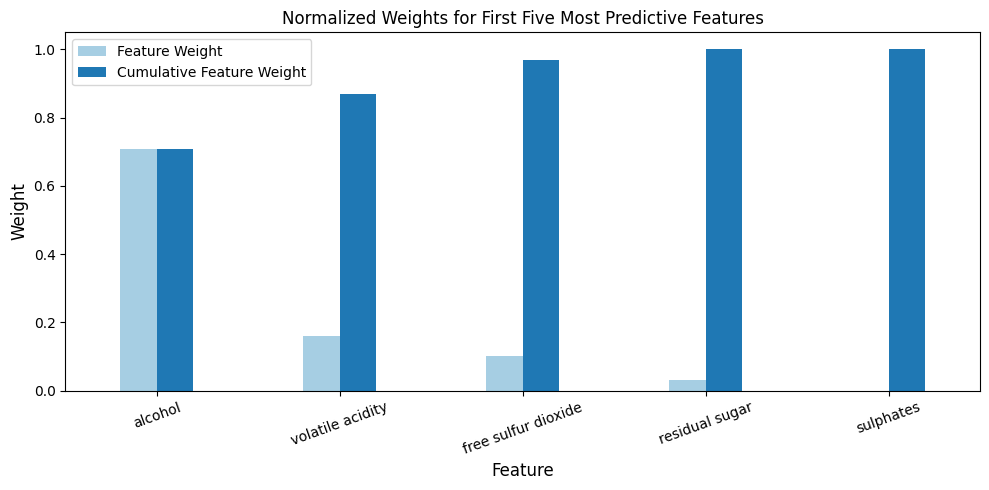

In [23]:
importances = decisionTreeClassifier.feature_importances_
colors = [plt.cm.Paired(i) for i in range(12)]
indices = np.argsort(importances)[::-1]
columns = X_train.columns.values[indices[:5]]
values = importances[indices][:5]

# Creat the pltot
fig = plt.figure(figsize = (10, 5))
plt.title("Normalized Weights for First Five Most Predictive Features")
plt.bar(np.arange(5) - 0.1, values, width = 0.2, align="center", color=colors[0], \
      label = "Feature Weight")
plt.bar(np.arange(5) + 0.1, np.cumsum(values), width = 0.2, align = "center", color=colors[1], \
      label = "Cumulative Feature Weight")
plt.xticks(np.arange(5), columns, rotation=20)
plt.xlim((-0.5, 4.5))
plt.ylabel("Weight", fontsize = 12)
plt.xlabel("Feature", fontsize = 12)

plt.legend()
plt.tight_layout()
plt.show() 

It turns out that 'alcohol' is by far the most important feature with a weight of over 70%. Adding 'volatile acidity' and 'free sulfur dioxide' already gives a cumulative weight of over 90%.

We finally look at the accuracy of the predictions per quality label:

In [24]:
res_test = pd.concat([y_test.reset_index(drop=True), pd.Series(predictions_test_opt).reset_index(drop=True)], axis=1)
res_test.columns = ['y_test','predictions_test_opt']
res_test['correct'] = res_test.y_test==res_test.predictions_test_opt
res_test_grouped = res_test.groupby(['y_test', 'correct']).size().reset_index(name='counts');
res_test_grouped['total'] = res_test_grouped.groupby('y_test')['counts'].transform('sum')
res_test_grouped['proportion'] = res_test_grouped['counts'] / res_test_grouped['total']

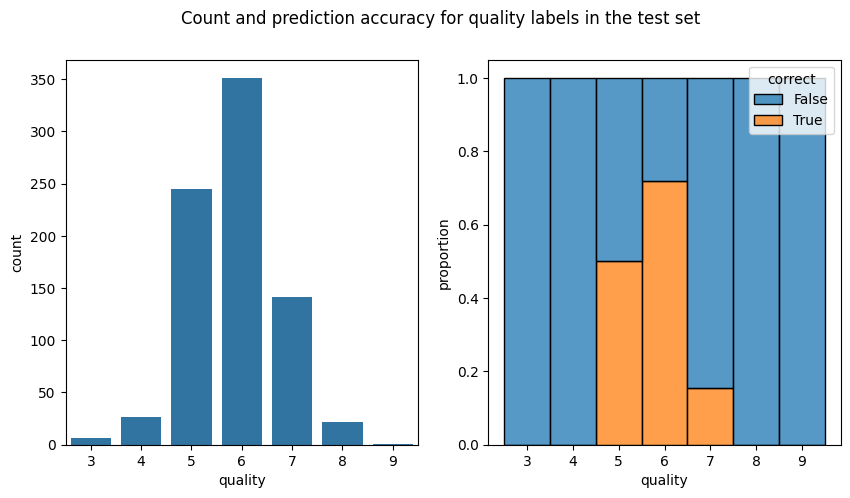

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Count and prediction accuracy for quality labels in the test set')
sns.countplot(data=res_test, x='y_test', ax=ax[0]);
ax[0].set(xlabel='quality', ylabel='count')
sns.histplot(res_test_grouped, ax=ax[1], x='y_test', hue='correct', weights='proportion', multiple='stack', bins=[2.5,3.5,4.5,5.5,6.5,7.5,8.5,9.5]);
ax[1].set(xlabel='quality', ylabel='proportion')
plt.show()

The most frequent quality label 6 in the data is also the one that our model predicts most accurately, with an accuracy of over 70%. Label 5 has an accuracy of around 50%, while the less frequent labels have a very poor accuracy.

This raises the question whether our model is actually doing better than a naive model that always predicts the most frequent label 6 for the test set? The answer is yes, albeit not by a huge margin, as the decision tree accuracy is 51% and the naive model's accuracy is 44%: 

In [26]:
predictions_test_flat6 = 6 * np.ones(len(y_test))
acc_test_flat6 = accuracy_score(y_test, predictions_test_flat6)
print(f'Test accuracy using constant prediction at quality level 6: {acc_test_flat6}')

Test accuracy using constant prediction at quality level 6: 0.4426229508196721


<a id='summary'></a>
### Summary

We have analyzed a dataset on the quality of white wine given its chemical properties. The dataset has 5,000 rows, eleven continuous feature columns, and the discrete target variable 'quality' ranging from 0 to 10. The dataset had no missing values, but a significant amount of duplicates. We made an active decision to remove these duplicates, ending up with around 4,000 rows. We then rescaled the features and split the data into a training and test batch, before training a decision tree classifier model. The model perfectly fitted the training data, and comparing training and test accuracy showed clear signs of overfitting. Therefore,  a regularization using cost-complexity pruning was performed, and the resulting model has a training accuracy of 54% and a test accuracy of 51%. Looking at feature importance showed that the top-three features have a cumulative weights of over 90%. We finally looked at accuracy on the test set per quality label, which revealed that the most frequent label 6 is predicted with over 70% accuracy, while the less frequent labels had a very poor accuarcy close to 0%. At least, our model is doing better than a naive model that always predicts the most frequent level.

The fact that the dataset is heavily skewed towards the intermediate quality labels 5, 6, and 7 is a limitation in fitting a model that is also accurate on low and high quality labels. It should also be noted that our decision to remove duplicates is a potential source of bias, as it is not clear whether these duplicates are data errors or genuine observations.

In [27]:
# Let us finally generate the requirements file for reproducibility.
!pip freeze > requirements.txt